# Load Skeletons (from cache)

Reloads a `BrainDataset` previously saved by `load_skeletons.ipynb` via `dataset.save(...)`. Skips the expensive SWC read + graph-building pass.

### Imports

In [1]:
import numpy as np
import os

from agentic_neuron_proofreader.utils import img_util, util
from agentic_neuron_proofreader.data_modules.datasets import BrainDataset

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "zihan_gcs_token.json"
os.environ["AWS_EC2_METADATA_DISABLED"] = "true"

## Section 1: Load From Cache

In [ ]:
brain_id = "794495"
segmentation_id = "raw.unet_449_splits_and_merges_900000"

cache_path = f"dataset_cache_{brain_id}.pkl"
dataset = BrainDataset.load_from_cache(cache_path)

segmentation_path = f"gs://allen-nd-goog/from_google/{brain_id}/whole_brain/{segmentation_id}/"
segmentation = img_util.TensorStoreImage(segmentation_path)

print(dataset.fragments_graph.summary(prefix="Fragments"))
print(dataset.gt_graph.summary(prefix="GroundTruth"))

I0524 00:10:05.977120 116003507 google_auth_provider.cc:149] Using credentials at zihan_gcs_token.json
I0524 00:10:05.977823 116003507 google_auth_provider.cc:165] Using ServiceAccount AuthProvider


Fragments Graph
# Connected Components: 10,172
# Nodes: 4,281,310
# Edges: 4,271,138
Memory Consumption: 6.34 GBs
GroundTruth Graph
# Connected Components: 19
# Nodes: 1,363,808
# Edges: 1,363,789
Memory Consumption: 6.21 GBs


### Combined Visualization: Image + UNet Segmentation + Skeletons

GT nodes / edges / components in patch:        77 / 75 / 1
Fragment nodes / edges / components in patch:  64 / 61 / 3


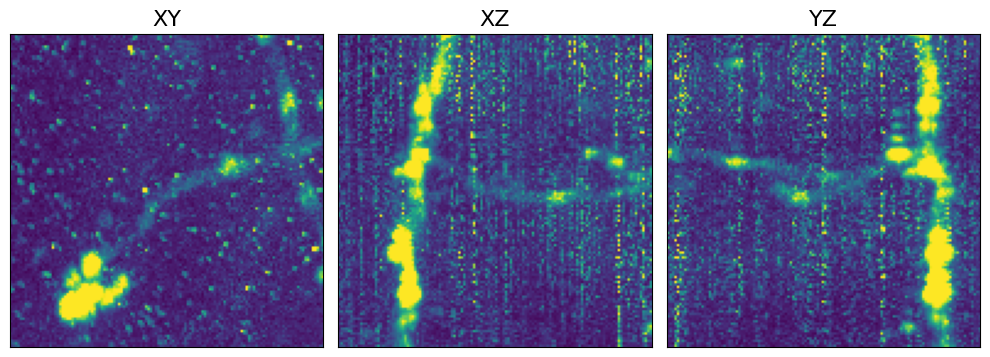

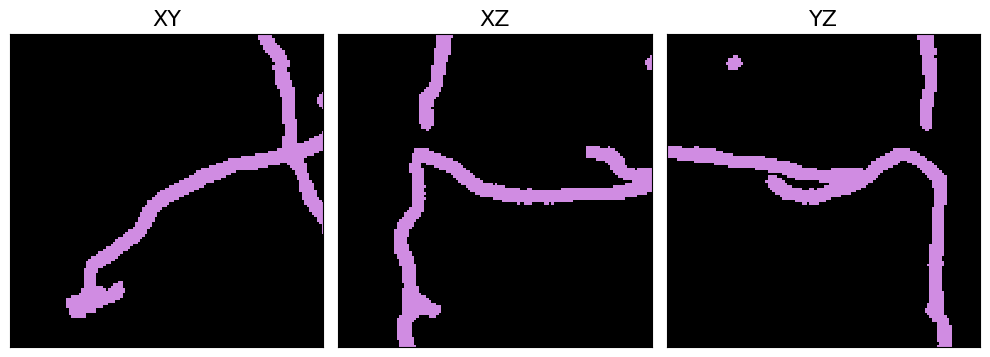

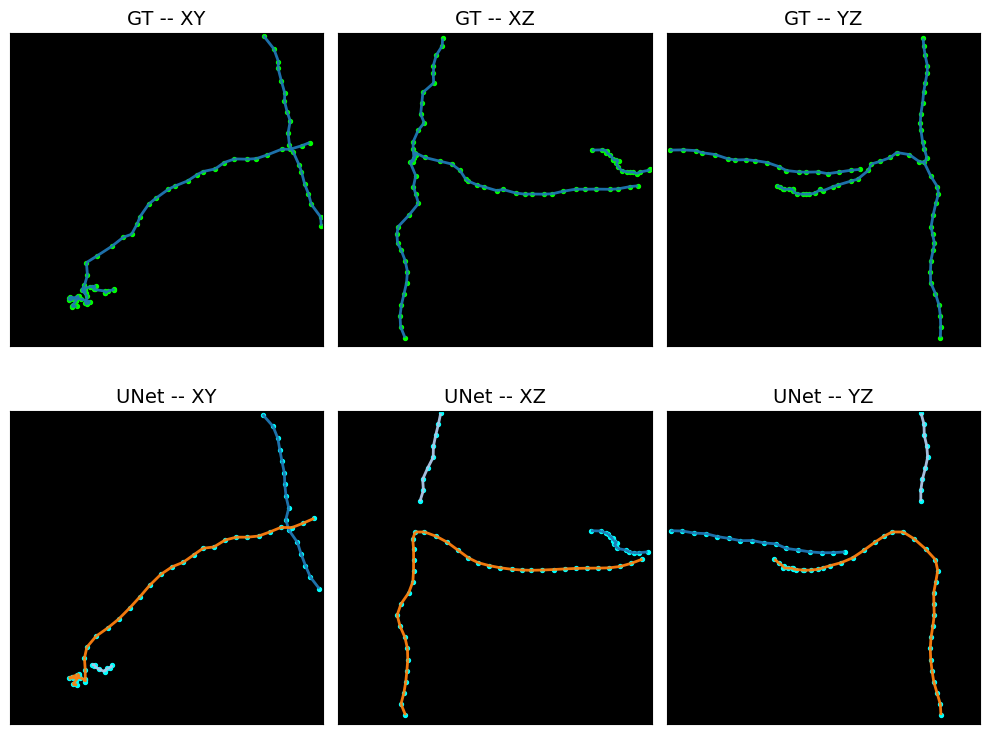

In [8]:
# Parameters
patch_shape = (128, 128, 128) 
use_groundtruth = True

# Sample a center voxel from either GT or UNet fragments graph
src_graph = dataset.gt_graph if use_groundtruth else dataset.fragments_graph
node = util.sample_once(src_graph.nodes)
center_voxel = src_graph.node_voxel(node)

# Read aligned image + segmentation patches at the same location
img_patch = dataset.img.read(center_voxel, patch_shape)
seg_patch = segmentation.read(center_voxel, patch_shape)
seg_mask = (seg_patch > 0).astype(int)

# Patch origin in global voxel space (for converting global -> local coords)
offset = tuple(c - s // 2 for c, s in zip(center_voxel, patch_shape))

# Find skeleton nodes + edges inside the patch. Asking for component IDs lets
# the plotter color each connected component differently per group (GT, UNet),
# which is the easiest visual cue for "are these two pieces the same fragment?"
gt_nodes = dataset.gt_graph.nodes_in_patch(offset, patch_shape)
gt_edges, gt_comps = dataset.gt_graph.edges_in_patch(
    offset, patch_shape, return_components=True
)
frag_nodes = dataset.fragments_graph.nodes_in_patch(offset, patch_shape)
frag_edges, frag_comps = dataset.fragments_graph.edges_in_patch(
    offset, patch_shape, return_components=True
)
print(f"GT nodes / edges / components in patch:        "
      f"{len(gt_nodes)} / {len(gt_edges)} / {len(np.unique(gt_comps))}")
print(f"Fragment nodes / edges / components in patch:  "
      f"{len(frag_nodes)} / {len(frag_edges)} / {len(np.unique(frag_comps))}")

# Plot image, UNet mask, and skeletons (GT and UNet on separate rows). Edges
# are colored per connected component within each group; nodes still use the
# group's base color so the GT vs UNet distinction stays legible.
img_util.plot_mips(img_patch)
img_util.plot_segmentation_mips(seg_mask)
img_util.plot_skeleton_mips(
    {
        "GT": {
            "nodes": gt_nodes,
            "edges": gt_edges,
            "components": gt_comps,
            "color": "lime",
        },
        "UNet": {
            "nodes": frag_nodes,
            "edges": frag_edges,
            "components": frag_comps,
            "color": "cyan",
        },
    },
    patch_shape,
    separate_rows=True,
)